In [1]:
# main.py
import sys
import os
import re
import string
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

import matplotlib.dates as mdates

import geopandas

# Add the parent directory of your module to sys.path
module_path = "/Users/joel/PyProjects/police-journal"
sys.path.insert(0, module_path)

from pdf_processor import GranbyPDFProcessor

In [2]:
pd.__version__

'3.0.0rc1'

In [3]:
plt.rcParams['font.family'] = ['Helvetica Neue', 'Arial', 'DejaVu Sans' ]
pd.set_option('display.max_rows', 25)

date_format = mdates.DateFormatter('%b %Y')

In [4]:
geopath = "/Users/Shared/Granby_Police_Journals/geocoding"
geofile = os.path.join(geopath, "addresses_with_zips_geocodio_c82e6800d9ad78f18ce0c13b17071865a810bf95.csv")

# Initialize processor
processor = GranbyPDFProcessor(pdf_directory="/Users/Shared/Granby_Police_Journals", verbose=False)

In [5]:
# Process all PDFs and create DataFrame
df = processor.process_all_pdfs()

2025-12-24 17:50:43,628 - INFO - Found 160 PDF files to process
2025-12-24 17:50:45,240 - INFO - Created DataFrame with 6875 total records


In [6]:
# date ranges
early = df['Dispatch Date'].min().strftime("%b. %d, %Y")
late = df['Dispatch Date'].max().strftime("%b. %d, %Y")

exclusions = "Not shown: school traffic control, mutual aid, civil matters, and debriefs/paperwork."

In [7]:
df.set_index('Dispatch Timestamp', inplace=True)
df.sort_index(inplace=True)

df['Officer ID'], _ = pd.factorize(df['Primary Officer'])

df['Officer Count'] = df['Officer ID'].rolling(window='120min', center=True).nunique(numeric_only=False)
df['Dispatch Timestamp'] = df.index.values

In [8]:
df.head(5)

,CFS #,Dispatch Type,Call Type,Dispatch Date,Dispatch Time,Location,Unit Id,Primary Officer,File Date,Dispatch Hour,Call Category,Officer ID,Officer Count,Dispatch Timestamp
Dispatch Timestamp,,,,,,,,,,,,,,
2025-07-14 00:12:00,2500007968,17,BUSINESS CHECK,2025-07-14,00:12,"STOP & SHOP, 120 SALMON BROOK ST, GRANBY",260,"KUPCHIK, ADDISON",07-14-2025,0,Patrol,0,2.0,2025-07-14 00:12:00
2025-07-14 00:17:00,2500007969,17,BUSINESS CHECK,2025-07-14,00:17,"ARROW CONCRETE, 560 SALMON BROOK ST, GRANBY",266,"DELOY, TYSON",07-14-2025,0,Patrol,1,2.0,2025-07-14 00:17:00
2025-07-14 00:29:00,2500007970,17,BUSINESS CHECK,2025-07-14,00:29,"WINDSOR FEDERAL SAVINGS BANK, 21 HARTFORD AVE,...",260,"KUPCHIK, ADDISON",07-14-2025,0,Patrol,0,2.0,2025-07-14 00:29:00
2025-07-14 00:41:00,2500007971,17,BUSINESS CHECK,2025-07-14,00:41,"CUMBERLAND FARMS, 19 HARTFORD AVE, GRANBY",260,"KUPCHIK, ADDISON",07-14-2025,0,Patrol,0,2.0,2025-07-14 00:41:00
2025-07-14 01:25:00,2500007972,17,BUSINESS CHECK,2025-07-14,01:25,"87 SIMSBURY RD, GRANBY",260,"KUPCHIK, ADDISON",07-14-2025,1,Patrol,0,2.0,2025-07-14 01:25:00


In [9]:
check911 = ((df['Call Type'].str.contains('911') & (df['Primary Officer'].str.len() > 1))).astype('int')
df['Call Type'] = df['Call Type'].where(check911 == 0, '911 RESPONSE')

### 11pm to 5am

In [10]:
# move 11:01pm to 12:01 so it is "next day"
df['Week'] = (df['Dispatch Timestamp'] + pd.Timedelta(hours=1)).dt.to_period('W').dt.start_time.dt.date
df['Dispatch Night'] = (df['Dispatch Timestamp'] + pd.Timedelta(hours=1)).dt.date
# filter to "overnight" patrols - 11pm-4:59am becomes 12am-5:50p
g = df[(df['Call Category'] == 'Patrol') 
        & ((df['Dispatch Timestamp'] + pd.Timedelta(hours=1)).dt.hour < 6)
      ].groupby(['Dispatch Night', 'Call Type']).agg({'CFS #': 'count', 'Unit Id': 'nunique'}).reset_index(level=1, drop=False)
g.rename(columns={'CFS #': 'Logs', 'Unit Id': 'Units'}, inplace=True)
dates = g.index.unique()
date_index = pd.date_range(start=dates.min(), end=dates.max())
g.reset_index(drop=False, inplace=True)
g.head()

,Dispatch Night,Call Type,Logs,Units
0,2025-07-14,BUSINESS CHECK,9,2
1,2025-07-14,NEIGHBORHOOD CHECK,1,1
2,2025-07-15,BUSINESS CHECK,7,2
3,2025-07-15,NEIGHBORHOOD CHECK,4,1
4,2025-07-16,BUSINESS CHECK,8,2


In [11]:
gg = g.melt(id_vars=['Dispatch Night', 'Call Type'])
gg = gg[gg.variable == 'Logs'].drop(columns='variable').set_index(['Dispatch Night', 'Call Type']).unstack().fillna(0).droplevel(level=0, axis=1)
gg = pd.DataFrame(date_index, index=date_index).join(gg, how='left')

In [12]:
hh = g.melt(id_vars=['Dispatch Night', 'Call Type'])
hh = hh[hh.variable == 'Units'].drop(columns='variable').set_index(['Dispatch Night', 'Call Type']).unstack().fillna(0).droplevel(level=0, axis=1)
hh = pd.DataFrame(date_index, index=date_index).join(hh, how='left')

In [13]:
#patrols between 11pm and 5am
ave_patrol_off = df[(df['Call Category'] == 'Patrol') 
                    & ((df['Dispatch Timestamp'] + pd.Timedelta(hours=1)).dt.hour < 6)
                   ].groupby(['Dispatch Night']).agg({'Officer Count': 'mean'})

In [14]:
hh = hh.join(ave_patrol_off)

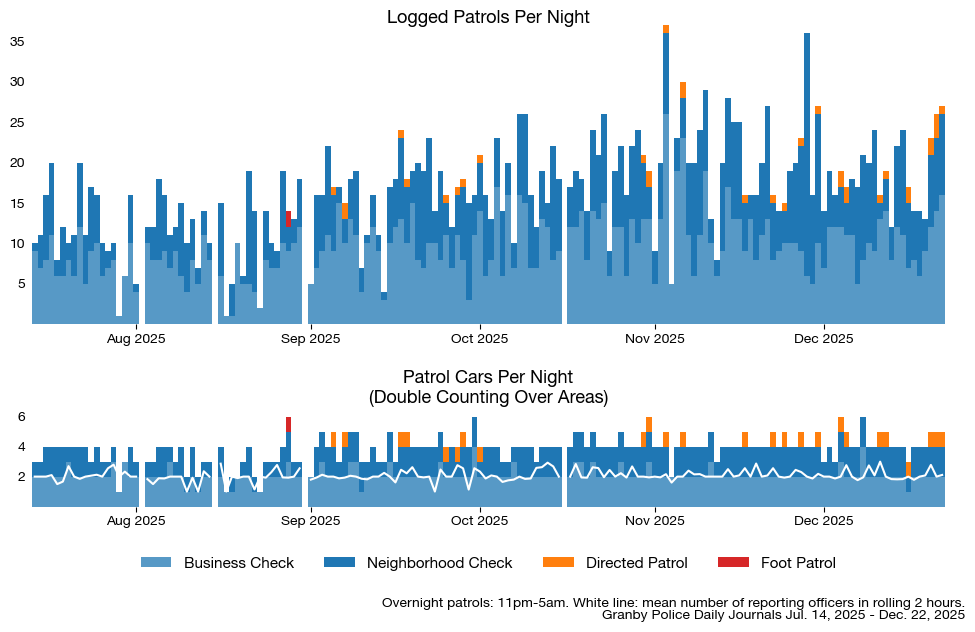

In [15]:
fig, axs = plt.subplots(2,1, figsize=(12, 6.25), height_ratios=[2.5, 1], gridspec_kw={'hspace': 0.3})

ax = axs[0]
ax1 = axs[1]

ax.set_title("Logged Patrols Per Night", y=.98, fontsize=13, fontname='Helvetica Neue')
ax.bar(gg.index, gg['BUSINESS CHECK'], bottom=0, alpha=.75, width=1, label='Business Check')
ax.bar(gg.index, gg['NEIGHBORHOOD CHECK'], bottom=gg['BUSINESS CHECK'], color='tab:blue', alpha=1, width=1, label='Neighborhood Check')
ax.bar(gg.index, gg['DIRECTED MOTOR PATROL'], bottom=gg['BUSINESS CHECK']+gg['NEIGHBORHOOD CHECK'], width=1, label='Directed Patrol')
ax.bar(gg.index, gg['DIRECTED FOOT PATROL'], bottom=gg['BUSINESS CHECK']+gg['NEIGHBORHOOD CHECK']+gg['DIRECTED MOTOR PATROL'], color='tab:red', width=1, label='Foot Patrol')

ax.set_xlim(date_index.min() - pd.Timedelta(days=2), date_index.max() + pd.Timedelta(days=2))
ax.xaxis.set_major_formatter(date_format)
ax.tick_params(axis='both', left=False, bottom=True, labelfontfamily='Helvetica Neue')
ax.tick_params(axis='y', which='major', pad=-5)

yticks = ax.get_yticks()
yticks = [y for y in yticks if (y > 0) & (y < 40)]
ylabs = [f"{x:.0f}" for x in yticks if x > 0]
ax.set_yticks(yticks, ylabs)

#ax.grid(which='major', axis='y', linestyle='-', color='white', alpha=.6, lw=.5, zorder=4)
ax.spines[:].set_visible(False)

##### bottom plot

ax1.set_title("Patrol Cars Per Night\n(Double Counting Over Areas)", y=.8, fontsize=13, fontname='Helvetica Neue')

ax1.bar(hh.index, hh['BUSINESS CHECK'], bottom=0, alpha=.75, width=1, label='Business Check')
ax1.bar(hh.index, hh['NEIGHBORHOOD CHECK'], bottom=hh['BUSINESS CHECK'], color='tab:blue', alpha=1, width=1, label='Neighborhood Check')
ax1.bar(hh.index, hh['DIRECTED MOTOR PATROL'], bottom=hh['BUSINESS CHECK']+hh['NEIGHBORHOOD CHECK'], width=1, label='Directed Patrol')
ax1.bar(hh.index, hh['DIRECTED FOOT PATROL'], bottom=hh['BUSINESS CHECK']+hh['NEIGHBORHOOD CHECK']+hh['DIRECTED MOTOR PATROL'], color='tab:red', width=1, label='Foot Patrol')
ax1.plot(hh.index, hh['Officer Count'], c='white')

ax1.set_ylim(0,8)
ax1.set_xlim(date_index.min() - pd.Timedelta(days=2), date_index.max() + pd.Timedelta(days=2))
ax1.xaxis.set_major_formatter(date_format)
ax1.tick_params(axis='both', left=False, bottom=True, labelfontfamily='Helvetica Neue')
ax1.tick_params(axis='y', which='major', pad=-5)

yticks = ax1.get_yticks()
yticks = [y for y in yticks if (y > 0) & (y <= 6)]
ylabs = [f"{x:.0f}" for x in yticks if x > 0]
ax1.set_yticks(yticks, ylabs)

#ax.grid(which='major', axis='y', linestyle='-', color='white', alpha=.6, lw=.5, zorder=4)
ax1.spines[:].set_visible(False)

ax1.legend(ncols=4, frameon=False, loc='lower center',  bbox_to_anchor=(0.5, -0.65), prop={'size':11, 'family':'Helvetica Neue'})

nighttime = 'Overnight patrols: 11pm-5am. White line: mean number of reporting officers in rolling 2 hours.'
plt.figtext(.91, -.05, nighttime, ha='right',
            fontsize=10, fontstyle='italic', fontname='Helvetica Neue')
plt.figtext(.91, -.07, f"Granby Police Daily Journals {early} - {late}", ha='right',
            fontsize=10, fontstyle='italic', fontname='Helvetica Neue')   

plt.savefig('/Users/joel/Desktop/granby_police_patrols.png', dpi=300, bbox_inches='tight', pad_inches=0.125)

plt.show()

In [16]:
cats = df[df['Call Type'] != 'POLICE INFO'].groupby('Call Category')['Call Type'].nunique().sort_values(ascending=False)
cats = cats[cats > 3]
cats

Call Category
Criminal           16
Administrative     14
Motor Vehicle      14
Emergency           7
Medical/Welfare     7
Complaint           6
Investigation       6
Patrol              5
Alarms              4
Name: Call Type, dtype: int64

In [17]:
g = df[(df['Call Type'] != 'POLICE INFO')].groupby('Call Category')['Call Type'].value_counts().sort_values()
g2 = df[(df['Call Type'] != 'POLICE INFO') & (df['Primary Officer'].str.len() > 0)].groupby('Call Category')['Call Type'].value_counts().sort_values()
g2.name = 'officers'

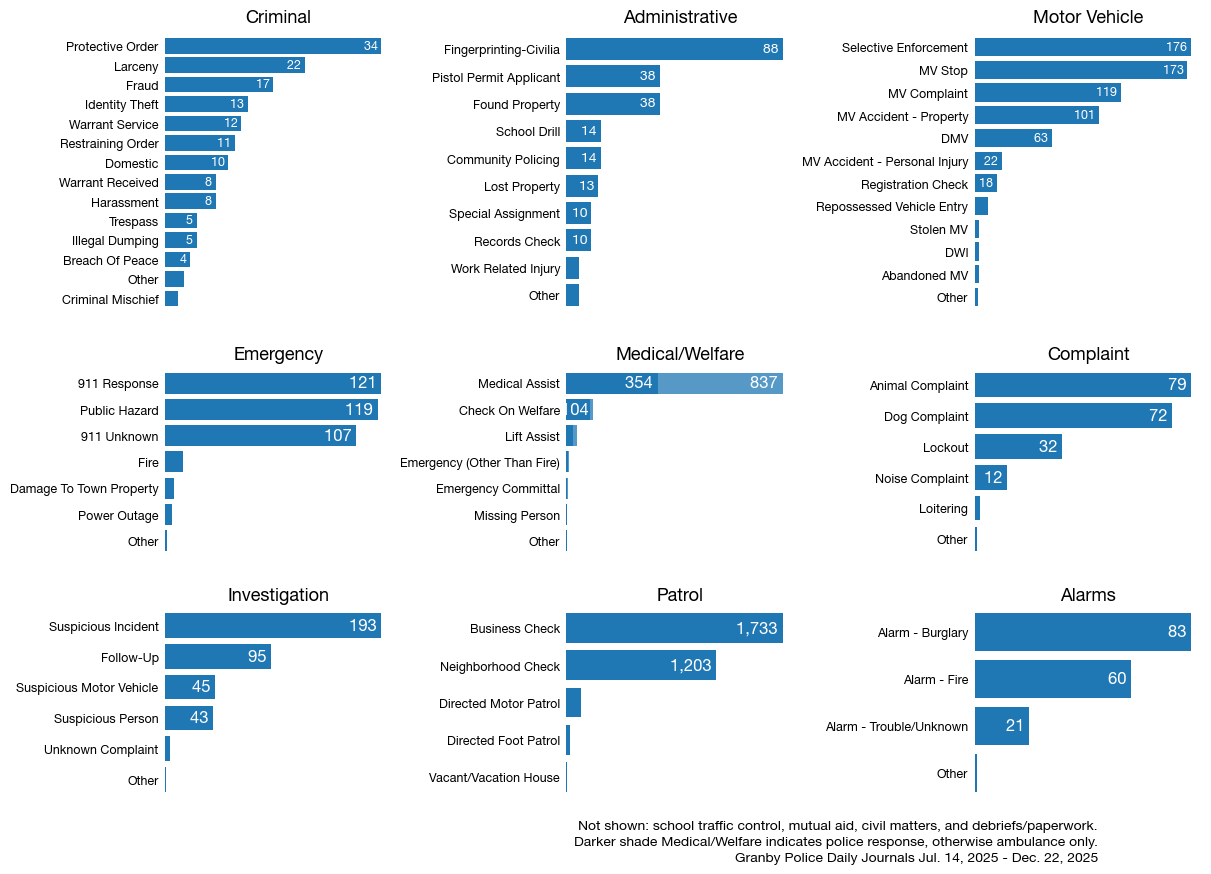

In [18]:
# Create figure
fig, axs = plt.subplots(3, 3, figsize=(12, 8), layout="constrained",
                        height_ratios=[1.5, 1, 1],
                        gridspec_kw={'hspace': 0.1})

for j, ax in enumerate(axs.flat):

    gg = g.loc[cats.index[j], :].copy()
    gg = gg.reset_index()

    # combine call types with only one count
    gg['Call Type'] = gg['Call Type'].where(gg['count']>1, 'Other')
    gg = gg.groupby('Call Type')['count'].sum().sort_values(ascending=True)
    gg = gg.reset_index()
    last = gg.index.max()
    
    if cats.index[j] == 'Medical/Welfare':
        gg = pd.DataFrame(g.loc['Medical/Welfare', :]).join(g2, how='left').fillna(0).reset_index()
        gg['ambulance'] = gg['count'] - gg['officers']
        gg['Call Type'] = gg['Call Type'].where(gg['count']>1, 'Other')
        gg = gg.groupby('Call Type').agg('sum').sort_values(by='count', ascending=True)
        gg = gg.reset_index(drop=False)
        last = gg.index.max()

    gg['Call Type'] = gg['Call Type'].where(gg['Call Type'].str.len()<4, gg['Call Type'].str.title())
    gg['Call Type'] = gg['Call Type'].str.replace("Mv", "MV")
    gg['Call Type'] = gg['Call Type'].str.replace("AMV", "Abandoned MV")


    if cats.index[j] == 'Medical/Welfare':
        ax.barh(gg.index.values, gg['officers'], xerr=None, align='center', color='tab:blue')
        ax.barh(gg.index.values, gg['ambulance'], left=gg['officers'], xerr=None, align='center', color='tab:blue', alpha=.75)
        
    else:
        ax.barh(y=gg.index.values, width=gg['count'], xerr=None, align='center')
    
    ax.set_title(cats.index[j], y=.98, fontsize=13, fontname='Helvetica Neue')
    ax.tick_params(axis='x', top=False, bottom=False, labeltop=False, labelbottom=False)
    ax.tick_params(axis='y', left=False, labelbottom=True, pad=1)
    ax.set_yticks(gg.index, labels=gg['Call Type'], fontsize=9, fontname='Helvetica Neue')

    # internal bar numbering, hack to print only if bar is over 10% length of longest
    # adjust fontsize
    fs = 12
    if last > 9:
        fs = 9
    elif last > 6:
        fs = 10
    for i in range(0, last):
        if gg.loc[last-i]['count'] >= .09 * gg.loc[last]['count']:
            axa = ax.annotate(f"{gg.loc[last-i]['count']:,.0f} ", xy=(gg.loc[last-i]['count'], last-i), color="white",
                                       ha='right', va='center', fontsize=fs, fontname='Helvetica Neue')
            if (cats.index[j] == 'Medical/Welfare') & (gg.loc[last-i]['Call Type'] == 'Medical Assist'):
                axa = ax.annotate(f"{gg.loc[last-i]['officers']:,.0f} ", xy=(gg.loc[last-i]['officers'], last-i), color="white",
                               ha='right', va='center', fontsize=fs, fontname='Helvetica Neue')
                

    ax.spines[:].set_visible(False)

plt.figtext(.91, -.03, exclusions, ha='right',
            fontsize=10, fontstyle='italic', fontname='Helvetica Neue')

plt.figtext(.91, -.05, "Darker shade Medical/Welfare indicates police response, otherwise ambulance only.", ha='right',
            fontsize=10, fontstyle='italic', fontname='Helvetica Neue')

plt.figtext(.91, -.07, f"Granby Police Daily Journals {early} - {late}", ha='right',
            fontsize=10, fontstyle='italic', fontname='Helvetica Neue')   


plt.savefig('/Users/joel/Desktop/granby_police_subtotals.png', dpi=300, bbox_inches='tight', pad_inches=0.125)

plt.show()

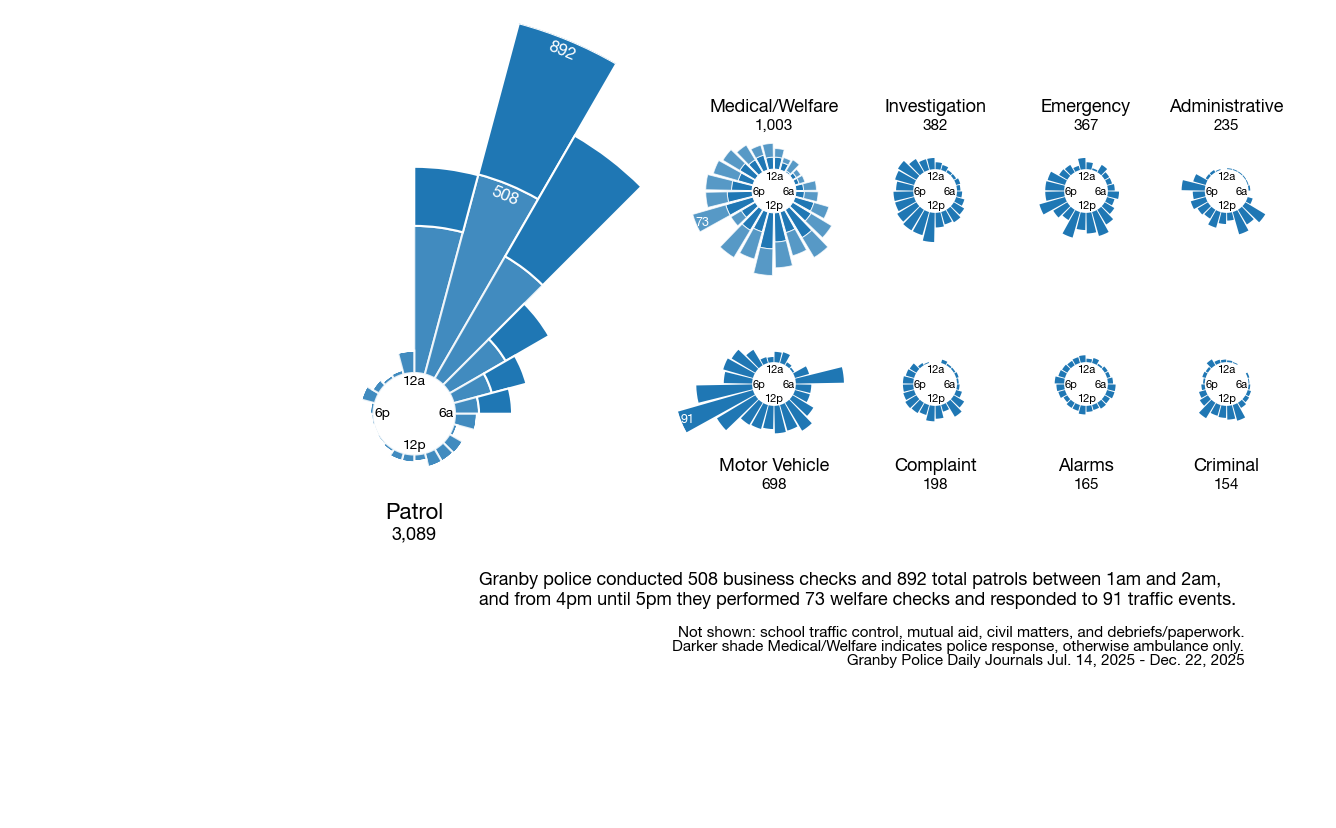

In [19]:
# hourly totals by category
hourly_calls = df[df['Call Type'] != 'POLICE INFO'].groupby('Call Category')['Dispatch Hour'].value_counts()
hourly_officers = df[(df['Call Type'] != 'POLICE INFO') & (df['Primary Officer'].str.len() > 0)].groupby('Call Category')['Dispatch Hour'].value_counts()
total_calls = df[df['Call Type'] != 'POLICE INFO']['Call Category'].value_counts()

wm_max = hourly_calls.loc['Medical/Welfare'].max()
mv_max = hourly_calls.loc['Motor Vehicle'].max()

categories = ['Medical/Welfare',  'Investigation', 'Emergency', 'Administrative',  'Motor Vehicle', 'Complaint', 'Alarms', 'Criminal']

# limits for shared axes (for set_ylim())
max_barheight = hourly_calls.loc[categories].max()
barstart = .28 * max_barheight

# angle-based x-axis, shift so midnight on top centered
theta = np.linspace(0.0, 2 * np.pi, 24, endpoint=False)
theta = theta - np.pi/2 + np.pi/24
timelabels = ['6a', '12p', '6p', '12a']
timeangles = np.array([0, np.pi/2, np.pi, 3*np.pi/2])

# Create figure
fig = plt.figure(figsize=(17, 7), layout=None)

# use two left columns for a bigger chart
# use hspace/wspace to squeeze together
gs = fig.add_gridspec(nrows=4, ncols=6, left=0.01, right=0.99,
                      hspace=-0.05, wspace=-0.4, 
                      height_ratios=[.4, 1.25, 1.25, .6],
                      width_ratios=[1.5, 1.5, .8, .8, .75, .75]
                     )

# Create the large left subplot (spans all rows and first 2 columns)
ax_large = fig.add_subplot(gs[:, 0:2], projection='polar', frameon=False)

# Create the 8 smaller subplots on the right
axs = []
for row in range(1, 3):
    for col in range(2, 6):
        ax = fig.add_subplot(gs[row, col], projection='polar', frameon=False)
        axs.append(ax)

# Plot on the 8 smaller subplots
for i, ax in enumerate(axs):
    
    category = categories[i]
    calls = hourly_calls.loc[category].reindex(range(24), fill_value=0).values
    labls = [f"{c:0.0f}" for c in calls]
    
    if category == 'Medical/Welfare':
        officers = hourly_officers.loc[category].reindex(range(24), fill_value=0).values
        ambulances = calls - officers

        ax.bar(theta, officers, width=np.pi/14, bottom=barstart,
               edgecolor='white', lw=.7, color='tab:blue', alpha=1)
        ax.bar(theta, ambulances, width=np.pi/14, bottom=barstart + officers,
               edgecolor='white', lw=.7, color='tab:blue', alpha=.75)

    else:
        ax.bar(theta, calls, width=np.pi/14, bottom=barstart, alpha=1)
    
    ax.set_theta_direction(-1)
    ax.set_ylim(0, max_barheight+barstart)   
    ax.set_facecolor('none')
    ax.grid(visible=None)
    ax.set_yticklabels("")
    ax.set_xticklabels("")

    # titles: second-row titles are below
    cat_total = total_calls.loc[category]
    if i <=3:
        ax.text(x=0.5, y=0.9, s=category,
                ha='center', transform=ax.transAxes, fontsize='13', fontname='Helvetica Neue')
        ax.text(x=0.5, y=0.9-.09, s=f"{cat_total:,.0f}",
                ha='center', transform=ax.transAxes, fontsize='11', fontname='Helvetica Neue')
    #ax.set_title(f"{category}\n{cat_total:,.0f}", y=.8, fontsize='13', fontname='Helvetica Neue')
    else:
        ax.text(x=0.5, y=0.07, s=category,
                ha='center', transform=ax.transAxes, fontsize='13', fontname='Helvetica Neue')
        ax.text(x=0.5, y=0.07-.09, s=f"{cat_total:,.0f}",
                ha='center', transform=ax.transAxes, fontsize='11', fontname='Helvetica Neue')
        
    # for labeling largest bars in smaller multiples in the first column
    if i in (0, 4):
        written = 0
        for angle, posn, lab in zip(theta, calls, labls):
            if (posn == calls.max()) & (written == 0) & (angle > 1.8):
                written = 1
                ax.annotate(lab, xy=(angle + (20/np.pi), posn+.9*barstart), color="white",
                                  ha='left', va='top', fontsize=9,fontname='Helvetica Neue')
    # hours of day
    for angle, label in zip(timeangles, timelabels):
        ax.text(angle, .67*barstart, label, ha='center', va='center', fontsize=8, fontname='Helvetica Neue')

# Plot the big plot

## total patrols
max_calls = hourly_calls.loc['Patrol'].max()
ttls = hourly_calls.loc['Patrol'].reindex(range(24), fill_value=0)
labls = [f"{c:0.0f}" for c in ttls]

## business v. non-business
bus_patrol = df[(df['Call Type'] == 'BUSINESS CHECK') & (df['Call Category'] == 'Patrol')]['Dispatch Hour'].value_counts()
other_patrol = df[(df['Call Type'] != 'BUSINESS CHECK') & (df['Call Category'] == 'Patrol')]['Dispatch Hour'].value_counts()

## use "total" to overwrite on business patrol to remove white line
bus_patrol = bus_patrol.reindex(range(24), fill_value=0)
ottls = bus_patrol.values
olabls = [f"{c:0.0f}" for c in ottls]
bus_patrol = bus_patrol.where(ttls > 100, ttls)

other_patrol = other_patrol.reindex(range(24), fill_value=0)
other_patrol = other_patrol.where(ttls > 100, 0)

# inner bar is business check
large_offset = 100
ax_large.bar(theta, bus_patrol, width=np.pi/12, bottom=large_offset,
             alpha=0.85, edgecolor='white', lw=1.5  )

ax_large.bar(theta, other_patrol, width=np.pi/12, bottom=large_offset+bus_patrol,
             alpha=1, color='tab:blue', edgecolor='white', lw=1.5 )

ax_large.set_ylim(0,  max_calls+large_offset )
ax_large.set_facecolor('none')
ax_large.set_theta_direction(-1)
ax_large.grid(visible=None)
ax_large.set_yticklabels("")
ax_large.set_xticklabels("")
cat_total = total_calls.loc['Patrol']
ax_large.text(x=0.5, y=0.37, s='Patrol',
        ha='center', transform=ax_large.transAxes, fontsize='16', fontname='Helvetica Neue')
ax_large.text(x=0.5, y=0.37-.025, s=f"{cat_total:,.0f}",
        ha='center', transform=ax_large.transAxes, fontsize='13', fontname='Helvetica Neue')

for angle, posn, oposn, lab, olab in zip(theta, ttls, ottls, labls, olabls):
    if posn == ttls.max():
        ax_large.annotate(lab, xy=(angle - (2/360*np.pi), posn+large_offset-1), color='white',
                          ha='center', va='top', rotation= -(90+(180*angle/np.pi)), fontsize=12,fontname='Helvetica Neue')
    if oposn == ottls.max():
        ax_large.annotate(olab, xy=(angle - (2/360*np.pi), oposn+large_offset-1), color='white',
                          ha='center', va='top', rotation= -(90+(180*angle/np.pi)), fontsize=12,fontname='Helvetica Neue')
# hours of day
for angle, label in zip(timeangles, timelabels):
    ax_large.text(angle, .78*100, label, ha='center', va='center', fontsize=10,fontname='Helvetica Neue')

# adjust position [left, bottom, width, height]
pos = ax_large.get_position()
ax_large.set_position([pos.x0 + .02 , pos.y0 - 0.35, 1.5*pos.width, 1.5*pos.height])

# helpful text


note = f"Granby police conducted {ottls.max()} business checks and {ttls.max()} total patrols between 1am and 2am,"
note = note + f"\nand from 4pm until 5pm they performed {wm_max} welfare checks and responded to {mv_max} traffic events."
plt.figtext(.46, .065, note, fontsize=13, fontname='Helvetica Neue')


plt.figtext(.91, .02, exclusions, ha='right',
            fontsize=11, fontstyle='italic', fontname='Helvetica Neue')

plt.figtext(.91, .0, "Darker shade Medical/Welfare indicates police response, otherwise ambulance only.", ha='right',
            fontsize=11, fontstyle='italic', fontname='Helvetica Neue')

plt.figtext(.91, -.02, f"Granby Police Daily Journals {early} - {late}", ha='right',
            fontsize=11, fontstyle='italic', fontname='Helvetica Neue')

plt.savefig('/Users/joel/Desktop/granby_police_timing.png', dpi=300, bbox_inches='tight', pad_inches=0)

plt.show()

## Geocoding
### Address cleanup

In [20]:
# clean addresses

def address_only(txt):
    
    txt = txt.upper().strip()
    txt = " ".join(txt.split())
    txt = txt.replace(" ,", ",")
    txt = txt.replace("(CATI)", "")
    txt = txt.replace(", EAST, GRANBY", ", EAST GRANBY")
    txt = txt.replace("ROUTE 10 TIRE", "ROUTE TEN TIRE")
    txt = " ".join(txt.split())
    txt = txt.replace(",,", ",")
    txt = txt.replace(", ,", ",")
    txt = txt.replace(" ,", ",")
    txt = " ".join(txt.split())
    txt = txt.replace(", RD, ", " RD, ")
    txt = txt.replace(", DR, ", " DR, ")
    txt = txt.replace("SOUTHWICK, SOUTHWICK", ", SOUTHWICK")
    txt = txt.replace("FFLOYDVILLERD", "FLOYDVILLE RD")

    txt = txt.replace("FEEDING, HILLS", "FEEDING HILLS")
    txt = txt.replace("17R EAST GRANBY RD, 17R EAST GRANBY RD,", "17R EAST GRANBY RD,")
    txt = txt.replace("375R NORTH GRANBY RD, 375R NORTH GRANBY RD,", "375R NORTH GRANBY RD,")
    txt = txt.replace("125 LOST ACRES RD, 150 LOST ACRES RD,", "150 LOST ACRES RD,")
    txt = txt.replace("AT STATE, LINE", "AT STATE, LINE")
    txt = txt.replace("SOUTH CONGRAGATIONAL, CHURCH", "242 Salmon Brook St, Granby").upper()
    
    
    txt = txt.replace("WINDSOR, LOCKS", "WINDSOR LOCKS")
    if txt.endswith(("33 TURKEY HILLS ROAD", "SEYMOUR ROAD Apt #: 6F")):
        txt = txt + ", EAST GRANBY"

    if txt.endswith("CONNECTICUT VALLEY COMMONS, LLC"):
        txt = txt + ", 19 HARTFORD AVE, GRANBY"

    placename = ''
    address = ''
    ambulances = ('SIMS', '165MED', 'LAFD-T', 'I4-BLS', '47MED', 'LA6', 'SIMSAL', 'GA14', 'LA3', '6F', 'SUFF', 'CANT')

    amb = re.search(r"(?P<begin>.*)(?P<amb>, (SIMS|165MED|LAFD-T|I4-BLS|47MED|LA6|SIMSAL|GA14|LA3|6F|SUFF|CANT|MORELLI, LORRAINE|SAYLOR, LAUREN)$)", txt)
    try:
        txt = amb.group("begin").strip()
    except:
        pass
    
    # append granby if missing
    if txt.endswith((' RD', ' ROAD', ' DRIVE', ' AV', ' ST', ' PLACE', ' LANE', ' STREET')):
        txt = txt.strip() + ", GRANBY"
        
    # remove apartment numbers
    apt = re.search(r"(?P<begin>.*)(?P<apt>APT.*)(?P<granby>, (GRANBY|SIMSBURY|EAST GRANBY|BLOOMFIELD|WINDSOR LOCKS).*)", txt)
    if apt:
        txt = apt.group("begin").strip() + apt.group("granby")

    # separate placename as text preceding first digit
    txt = txt[::-1]
        
    substr = re.match(r"(?P<address>.+\d)?(?P<placename>.*)", txt)
    if substr:
        if substr.group('placename'):
            placename = substr.group('placename')[::-1].strip()
        if substr.group('address'):
            address = substr.group('address')[::-1].strip()
    else:
        address = txt[::-1]

    if address.strip() == "":
        address = placename
        placename = ""

    placename = placename.strip(",")
        
    address = address.replace(",,", ",")
    address = address.replace(", ,", ",")
    address = address.replace(" ,", ",")
    address = address.replace(" 'S","")
    address = address.replace("MURTHA'S WAY - DUPLEX, CONSTRUCTION, ", "")
    address = address.replace("219 LOOMIS ST, 218 LOOMIS ST,", "219 LOOMIS ST,")
    address = address.replace("280 APARTMENTS, ", "")
    address = address.replace("8 THRONEBROOK RD, 8 THRONEBROOK RD,","8 THRONEBROOK RD,")
    address = address.replace("66, 150","150")
    address = address.replace("HARTOLAND","HARTLAND")
    address = address.replace(" NEAR NEW CELL, TOWER SITE","")
    address = address.replace("STRAWBERRYFIELDS", "STRAWBERRY FIELDS")

    address = address.replace("AMERICAN LEGION HALL POST, #", "244 NORTH GRANBY RD, GRANBY")
    address = address.replace("SUFFIELD PD", "11 Mountain Road, Suffield").upper()
    address = address.replace("WESTFIELD PD, WESTFIELD MA", "15 WASHINGTON ST, WESTFIELD")
    address = address.replace("WESTFIELD POLICE", "15 WASHINGTON ST, WESTFIELD")
    address = address.replace("SIMSBURY PD", "933 Hopmeadow St, Simsbury").upper()
    address = address.replace("GRANVILLE PD, GRANVILLE MA", "707 Main Rd, Granville").upper()
    address = address.replace("TOLLAND PD MA", "204 W Granville Rd, Tolland").upper()
    address = address.replace("WINDSOR PD", "110 Addison Rd, Windsor").upper()
    if address == "GRANVILLE PD":
        address = "707 Main Rd, Granville".upper()
    if address == "WESTFIELD PD":
        address = "15 WASHINGTON ST, WESTFIELD".upper()
    
    address = address.replace("BERG FIELD", "93 Hartland Blvd, East Hartland").upper()
    address = address.replace("SALMON BROOK SOUTH OF, ROTARY", "577 SALMON BROOK ST, GRANBY")
    address = address.replace("SALMON BROOK ST AT STATE, LINE", "SALMON BROOK ST @ ZIMMER ST, GRANBY")
    address = address.replace("TRANSFER STATION", "103 Old Stagecoach Rd, Granby").upper()
    address = address.replace("GRANBY HIGH SCHOOL", "54 N Granby Rd, Granby, Granby").upper()
    address = address.replace("SALMON BROOK DISTRICT WATER, CO", "15R Hartford Ave, Granby").upper()
    address = address.replace("GRANBY POLICE DEPT", "15 N Granby Rd, Granby").upper()
    address = address.replace("4, BRADLEY AIRPORT", "23 Schoephoester Rd, Windsor Locks").upper()
    if address == "BRADLEY AIRPORT CONNECTOR":
        address = "BRADLEY AIRPORT CONNECTOR @ Poquonock Ave, Windsor Locks".upper()
    if address == "BRADLEY AIRPORT":
        address = "180 Schoephoester Rd, Windsor Locks".upper()
      
    if address == "91 NORTH @ BRAINARD EXIT":
        address = "91 NORTH @ BRAINARD EXIT, Windsor Locks".upper()

    if address.endswith(" MA"):
        address = address[:-3]
    
    if address.endswith(("33 TURKEY HILLS ROAD", "SEYMOUR ROAD APT #: 6F")):
        address = address + ", EAST GRANBY"

    amb = re.search(r"(?P<begin>.*)(?P<amb> (SIMS|165MED|LAFD-T|I4-BLS|47MED|LA6|SIMSAL|GA14|LA3|6F|SUFF|CANT|MORELLI, LORRAINE|SAYLOR, LAUREN)$)", address)
    try:
        address = amb.group("begin").strip()
    except:
        pass

    if address.count(",") > 1:
        address = address.replace(",", "", 1)
        address = " ".join(address.split())
        
    if address.count(",") < 1:
        if address in ["NORTH HOLLOW/ GRANVILLE", "PHELPS/QUARRY", "UPPER MEADOW"]:
            address = address + ", GRANBY"
    
    address = address.replace('/',' @ ')
    address = " ".join(address.split())
    
    return [placename, address]

In [21]:
def get_state(x):

    townlist = ['GRANBY', 'EAST GRANBY', 'SIMSBURY', 'HARTLAND', 'SUFFIELD', 'BARKHAMSTED', 'WINDSOR LOCKS', 'HARTFORD', 'WINDSOR', 'BLOOMFIELD', 'CANTON', 'NEWINGTON',
                'TORRINGTON', 'EAST HARTLAND', 'MANCHESTER', 'GREENWICH', 'WINSTED', 'TARIFFVILLE', 'AVON', 'BURLINGTON', 'NEW BRITIAN', 'BRISTOL', 'PLAINVILLE', 'VERNON']
    malist = ['SOUTHWICK', 'GRANVILLE', 'CHICOPEE', 'WESTFIELD', 'FEEDING HILLS', 'SPRINGFIELD', 'OTIS']
    
    if x in townlist:
        return 'CT'
    elif x in malist:
        return 'MA'
    else:
        return ''


In [22]:
def extract_street(x):
    
    if x.count(",") > 0:
        street = x.split(",")[0]
        street = street.strip()
        return street
    return x

def extract_streetname(x):
    
    if x.count(",") > 0:
        street = x.split(",")[0]
        street = re.sub(r'\d', '', street)
        street = street.strip()
        return street
    return x

In [23]:
address_only('SHIGLEY VILLAGE, 53 SOUTH MAIN ST Apt #: 11B, EAST granby')

['SHIGLEY VILLAGE', '53 SOUTH MAIN ST, EAST GRANBY']

### Make clean addresses

In [24]:
df['Place Name'] = df['Location'].apply(lambda x: address_only(x)[0])
df['Address'] = df['Location'].apply(lambda x: address_only(x)[1])
df['Town'] = df['Address'].apply(lambda x: x.split(",")[::-1][0].strip())
df['State'] = df['Town'].apply(lambda x: get_state(x))
df['State'] = df['State'].where(~df['State'].isna(), df['Location'].str[-2:])
df['State'] = df['State'].where(df['State'].isin(['CT', 'MA', 'NY']), "")

df['Street'] = df['Address'].apply(lambda x: extract_street(x))
df['Street Name'] = df['Address'].apply(lambda x: extract_streetname(x))

In [25]:
df.head(2)

,CFS #,Dispatch Type,Call Type,Dispatch Date,Dispatch Time,Location,Unit Id,Primary Officer,File Date,Dispatch Hour,...,Officer Count,Dispatch Timestamp,Week,Dispatch Night,Place Name,Address,Town,State,Street,Street Name
Dispatch Timestamp,,,,,,,,,,,,,,,,,,,,,
2025-07-14 00:12:00,2500007968,17,BUSINESS CHECK,2025-07-14,00:12,"STOP & SHOP, 120 SALMON BROOK ST, GRANBY",260,"KUPCHIK, ADDISON",07-14-2025,0,...,2.0,2025-07-14 00:12:00,2025-07-14,2025-07-14,STOP & SHOP,"120 SALMON BROOK ST, GRANBY",GRANBY,CT,120 SALMON BROOK ST,SALMON BROOK ST
2025-07-14 00:17:00,2500007969,17,BUSINESS CHECK,2025-07-14,00:17,"ARROW CONCRETE, 560 SALMON BROOK ST, GRANBY",266,"DELOY, TYSON",07-14-2025,0,...,2.0,2025-07-14 00:17:00,2025-07-14,2025-07-14,ARROW CONCRETE,"560 SALMON BROOK ST, GRANBY",GRANBY,CT,560 SALMON BROOK ST,SALMON BROOK ST


### Apply previous geocoding
#### geocodio

In [26]:
# Use geocodio geocoding 
geo = pd.read_csv(geofile)
geo = geo[geo['Accuracy Type'] != 'state']
geo['Accuracy Type'].value_counts()

Accuracy Type
rooftop                  1129
street_center             221
range_interpolation       185
intersection              167
nearest_rooftop_match      12
place                       8
Name: count, dtype: int64

In [27]:
# add geocodeio
df2 = df.merge(geo[['Street', 'Town', 'State', 'Postal Code', 'Latitude', 'Longitude', 'Accuracy Type', 'Accuracy Score']],
               on=['Street', 'Town', 'State'], how='left')

df2['ZIP Code'] = df2['Postal Code'].fillna(0).astype(int).astype(str).str.zfill(5)
df2 = df2.drop(columns=['Postal Code'])

# override middle/high school geocoding
df2['Latitude'] = df2['Latitude'].where(df2['Latitude'] != 41.960488, 41.960124921625656)
df2['Longitude'] = df2['Longitude'].where(df2['Longitude'] != -72.797766, -72.79283222814749)

# west granby post office 41.95656022764371, -72.83784229230196
df2['Latitude'] = df2['Latitude'].where(df2['Address'] != 'UNITED STATED POST OFFICE -, WEST', 41.956512355376255)
df2['Longitude'] = df2['Longitude'].where(df2['Address'] != 'UNITED STATED POST OFFICE -, WEST', -72.83784229230196)

# 41.99574606053045, -72.79701746212086
df2['Latitude'] = df2['Latitude'].where(~df2['Street'].isin(('EAST ST @ SALMON BROOK ST', 'SALMON BROOK ST @ EAST ST.', 'SALMON BROOK ST @ EAST ST')), 41.99574606053045)
df2['Longitude'] = df2['Longitude'].where(~df2['Street'].isin(('EAST ST @ SALMON BROOK ST', 'SALMON BROOK ST @ EAST ST.', 'SALMON BROOK ST @ EAST ST')), -72.79701746212086)

# 41.969110481349155, -72.79597160071273  
df2['Latitude'] = df2['Latitude'].where(~df2['Address'].str.contains('OLD MILL POND VILLAGE'), 41.969110481349155)
df2['Longitude'] = df2['Longitude'].where(~df2['Address'].str.contains('OLD MILL POND VILLAGE'), -72.79597160071273 )

# 41.95626351713422, -72.79282864824262
df2['Latitude'] = df2['Latitude'].where(~df2['Street'].isin(('W GRANBY RD @ N GRANBY RD', 'WEST GRANBY RD @ NORTH GRANBY RD')), 41.95626351713422)
df2['Longitude'] = df2['Longitude'].where(~df2['Street'].isin(('W GRANBY RD @ N GRANBY RD', 'WEST GRANBY RD @ NORTH GRANBY RD')), 72.79282864824262)

#### geoapify

In [28]:
# geoapify geocoding
geos = []
for fileidx in range(1,5):
    geos.append(pd.read_csv(f"/Users/Shared/Granby_Police_Journals/geocoding/geocoded_by_geoapify-12_21_2025_{fileidx}.csv"))

geocodes = pd.concat(geos).rename(columns={'lat': 'Latitude', 'lon': 'Longitude', 'original_state': 'State'})
geocodes['Address'] = geocodes['original_location'] + ", " + geocodes["original_town"]
geocodes['postcode'] = geocodes['postcode'].fillna(0).astype(int).astype(str).str.zfill(5)

print(geocodes.shape)

# remove "center of town" coding
geocodes = geocodes[(geocodes.Longitude != -72.789313) & (geocodes.Latitude != 41.953830)]
geocodes = geocodes[geocodes.confidence_street_level >= .7]
print(geocodes.shape)

(1723, 27)
(1499, 27)


In [29]:
#add geoapify to missing
df3 = df2[df2['Latitude'].isna()].drop(columns=['Latitude', 'Longitude', 'Accuracy Type', 'Accuracy Score'])\
                         .merge(geocodes[['Address', 'State', 'postcode', 'Latitude', 'Longitude']],
                                how='left', on=['Address', 'State']).rename(columns={'postcode': 'Postal Code'})

df3['ZIP Code'] = df3['Postal Code'].fillna(0).astype(int).astype(str).str.zfill(5)
df3 = df3.drop(columns=['Postal Code'])

df4 = df3[df3['Latitude'].isna()]
df3 = df3[df3['Latitude'].notna()]


#### ArcGIS
**Best for intersections**

Full dataset at `pd.read_parquet('/Users/Shared/Granby_Police_Journals/geocoding/granby_intersections.parquet')`

In [30]:
#[['Address', 'Street', 'Town', 'State', 'Status', 'Score', 'Rank', 'Addr_type', 'Postal', 'X','Y', 'ShortLabel', 'Match_addr' ]]
arcgeo = pd.read_csv('/Users/Shared/Granby_Police_Journals/geocoding/granby_intersections_geocoded.csv')\
           .rename(columns={'X': 'Longitude', 'Y': 'Latitude'})
arcgeo.shape

(407, 15)

In [31]:
arcgeo.head()

,Unnamed: 0,ReturnNo,Address,Street,Town,State,Status,Score,Rank,Addr_type,Postal,Longitude,Latitude,ShortLabel,Match_addr
0,0,0,"WELLS RD @ MEADOW BROOK RD, GRANBY",WELLS RD @ MEADOW BROOK RD,GRANBY,CT,M,100.00,20.0,StreetInt,6035.0,-72.807001,41.982008,Wells Rd & Meadowbrook Rd,"Wells Rd & Meadowbrook Rd, Granby, Connecticut..."
1,1,0,"NORTH GRANBY RD @ DANIELLE RD, GRANBY",NORTH GRANBY RD @ DANIELLE RD,GRANBY,CT,M,100.00,20.0,StreetInt,6035.0,-72.800020,41.961681,N Granby Rd & Danielle Rd,"N Granby Rd & Danielle Rd, Granby, Connecticut..."
2,2,0,"SILVER ST @ DOHERTY RD, GRANBY",SILVER ST @ DOHERTY RD,GRANBY,CT,M,98.14,20.0,StreetInt,6060.0,-72.840664,42.019834,Silver St & Doherty Rd,"Silver St & Doherty Rd, North Granby, Connecti..."
3,3,0,"EAST GRANBY RD @ LAUREL DR, GRANBY",EAST GRANBY RD @ LAUREL DR,GRANBY,CT,M,100.00,20.0,StreetInt,6035.0,-72.776982,41.954710,E Granby Rd & Laurel Dr,"E Granby Rd & Laurel Dr, Granby, Connecticut, ..."
4,4,0,"GRANVILLE RD @ NORTHWOODS RD, GRANBY",GRANVILLE RD @ NORTHWOODS RD,GRANBY,CT,M,98.14,20.0,StreetInt,6060.0,-72.863052,42.033944,Granville Rd & Northwoods Rd,"Granville Rd & Northwoods Rd, North Granby, Co..."


In [32]:
arcgeo.drop_duplicates(subset='Address').shape[0], arcgeo[arcgeo.ReturnNo == 0]['Addr_type'].value_counts().sum()

(254, np.int64(253))

In [33]:
origcols = [c for c in df.columns if c in df4.columns]
df4 = df4[origcols].merge(arcgeo[arcgeo.ReturnNo == 0][['Address', 'Town', 'State', 'Postal', 'Longitude', 'Latitude', 'Addr_type']],
                    how='left', on=['Address', 'Town', 'State']).rename(columns={'Addr_type': 'Accuracy Type'})

df4['ZIP Code'] = df4['Postal'].fillna(0).astype(int).astype(str).str.zfill(5)
df4 = df4.drop(columns=['Postal'])

#### double check row counts

In [34]:
df2[df2.Latitude.notna()].shape[0] + df3.shape[0] + df4.shape[0] - df.shape[0]

0

In [35]:
df = pd.concat([df2[df2.Latitude.notna()],df3,df4])

In [36]:
df['Call Category'].value_counts()

Call Category
Patrol             3089
Medical/Welfare    1003
Motor Vehicle       698
Administrative      428
Investigation       382
Emergency           367
Complaint           198
Traffic Control     170
Alarms              165
Criminal            154
Inter-Agency        105
Civil                71
Other                25
Juvenile             20
Name: count, dtype: int64

In [37]:



df[(df.State.str.len()>1) & (df.Longitude.isna())][['Location','Address', 'Street', 'Town', 'State']].value_counts().reset_index()





,Location,Address,Street,Town,State,count
0,"MURTHA'S WAY - DUPLEX, CONSTRUCTION Apt #: 522...",GRANBY,GRANBY,GRANBY,CT,1
1,SOUTHWICK,SOUTHWICK,SOUTHWICK,SOUTHWICK,MA,1
2,MANCHESTER,MANCHESTER,MANCHESTER,MANCHESTER,CT,1
3,521 FOREST ROAD,"521 FOREST ROAD, GRANBY",521 FOREST ROAD,GRANBY,CT,1
4,64 WOODSHOLLOW ROAD,"64 WOODSHOLLOW ROAD, GRANBY",64 WOODSHOLLOW ROAD,GRANBY,CT,1


In [38]:
with pd.option_context("display.max_rows", None, 'display.max_colwidth', 100):
    display(df[(df.State.str.len()>1) & (df.Longitude.isna())][['Address', 'Street', 'Town', 'State']].value_counts())

Address                      Street               Town        State
GRANBY                       GRANBY               GRANBY      CT       1
SOUTHWICK                    SOUTHWICK            SOUTHWICK   MA       1
MANCHESTER                   MANCHESTER           MANCHESTER  CT       1
521 FOREST ROAD, GRANBY      521 FOREST ROAD      GRANBY      CT       1
64 WOODSHOLLOW ROAD, GRANBY  64 WOODSHOLLOW ROAD  GRANBY      CT       1
Name: count, dtype: int64

### Make location summary

In [39]:
#with pd.option_context("display.max_rows", None, 'display.max_colwidth', 100):
rng = np.random.default_rng()

def obscure(x, denom=None):
    
    if denom is None:
        denom = 100
    return x + (np.random.rand() - .5)/denom

In [51]:
df.columns

Index(['CFS #', 'Dispatch Type', 'Call Type', 'Dispatch Date', 'Dispatch Time',
       'Location', 'Unit Id', 'Primary Officer', 'File Date', 'Dispatch Hour',
       'Call Category', 'Officer ID', 'Officer Count', 'Dispatch Timestamp',
       'Week', 'Dispatch Night', 'Place Name', 'Address', 'Town', 'State',
       'Street', 'Street Name', 'Latitude', 'Longitude', 'Accuracy Type',
       'Accuracy Score', 'ZIP Code'],
      dtype='str')

#### Write info

In [85]:
g = df[(df['Latitude'].notna()) & (~df['Call Category']\
      .isin(('Criminal', 'Administrative', 'Traffic Control', 'Inter-Agency', 'Civil','Other','Juvenile')))]\
      [['Week', 'Call Category', 'Call Type', 'Latitude', 'Longitude', 'Primary Officer']].copy()

# two different radius lengths - stretch in unpredictable directions!
g['rand_10a'] = (rng.beta(a=2.5, b=5, size=g.shape[0]))/250
g['rand_10b'] = (rng.beta(a=2.5, b=5, size=g.shape[0]))/250

# but one direction, so lat & long "stretch" in similar proportions
g['rand_direction'] = 2*np.pi*rng.random(size=g.shape[0])

# any investigation, emergency, criminal, etc., obscured
g['Latitude'] = g['Latitude'].where(g['Call Category'].isin(('Patrol', 'Motor Vehicle')), g['Latitude'] + g['rand_10a']*np.cos(g['rand_direction']))
g['Longitude'] = g['Longitude'].where(g['Call Category'].isin(('Patrol', 'Motor Vehicle')), g['Longitude'] + g['rand_10b']*np.sin(g['rand_direction']))

# small jitter to others
g['rand_1000a'] = (rng.random(g.shape[0]) - .5)/1200
g['rand_1000b'] = (rng.random(g.shape[0]) - .5)/1200
g['Latitude'] = g['Latitude'].where(~g['Call Category'].isin(('Patrol', 'Motor Vehicle')), g['Latitude'] + g['rand_1000a'])
g['Longitude'] = g['Longitude'].where(~g['Call Category'].isin(('Patrol', 'Motor Vehicle')),  g['Longitude'] + g['rand_1000b'])

g['Call Category'] = g['Call Category'].where(~g['Call Type'].str.contains('ACCIDENT'), lambda x: "Motor Vehicle Accident")
g['Call Category'] = g['Call Category'].where(~(g['Call Category']=="Motor Vehicle"), lambda x: "Motor Vehicle Enforcement")
g['Call Category'] = g['Call Category'].where(~((g['Call Category']== "Medical/Welfare") & (g['Primary Officer'].str.len() < 1)), lambda x: "Ambulance")

gg = g[['Week', 'Call Category', 'Call Type', 'Latitude', 'Longitude']].value_counts().reset_index(drop=False)

gg['Call Type'] = gg['Call Type'].str.title()
gg['Call Type'] = gg['Call Type'].str.replace("Mv", "MV")
gg['Call Type'] = gg['Call Type'].str.replace("AMV", "Abandoned MV")

gg.rename(columns={'count':'Number of Calls'}, inplace=True)
gg.to_csv('/Users/joel/Desktop/Police_Activity.csv', index=False)
    

In [86]:
g['Longitude'].describe()

count    5890.000000
mean      -72.626814
std         5.016757
min       -73.570528
25%       -72.815635
50%       -72.792909
75%       -72.787433
max        72.793522
Name: Longitude, dtype: float64

<Axes: ylabel='Frequency'>

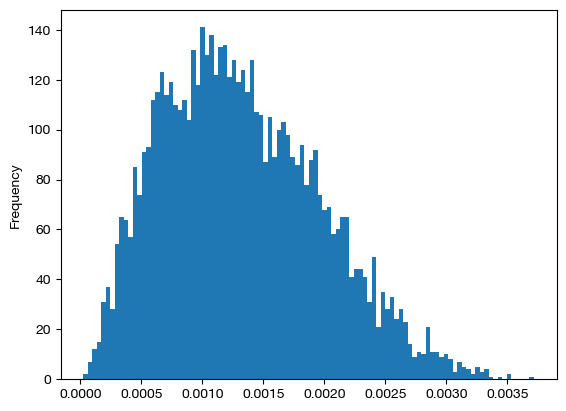

In [87]:
g['rand_10b'].plot(kind='hist', bins=100)

In [88]:
gg['Call Category'].value_counts()

Call Category
Patrol                       3089
Motor Vehicle Enforcement     575
Ambulance                     514
Medical/Welfare               485
Investigation                 382
Emergency                     359
Complaint                     198
Alarms                        165
Motor Vehicle Accident        123
Name: count, dtype: int64

In [89]:
gdf = geopandas.GeoDataFrame(
    gg,
    geometry=geopandas.points_from_xy(gg.Longitude, gg.Latitude),
    crs="EPSG:4326" # Set the Coordinate Reference System (WGS84 lat/lon)
)
gdf.to_file('/Users/joel/Desktop/Police_Activity.geojson', driver="GeoJSON")

2025-12-24 19:07:08,046 - INFO - Created 5,890 records


In [70]:
with pd.option_context("display.max_rows", None, 'display.max_colwidth', 100):
    display(df[df['Call Type'].isin(('SELECTIVE ENFORCEMENT', 'MV STOP'))]['Street Name'].value_counts())

Street Name
SALMON BROOK ST                        41
WEST GRANBY RD                         38
NORTH GRANBY RD                        35
MOUNTAIN RD                            19
EAST GRANBY RD                         16
SIMSBURY RD                            15
HUNGARY RD                              9
EAST ST                                 9
DAY ST                                  8
MOUNTAIN RD @ CIDER MILL HTS            7
BUSHY HILL RD @ GRANBY FARMS RD         7
HARTFORD AVE                            6
PARK PL                                 6
CANTON RD                               5
GENIS HILL RD                           5
SILVER ST                               4
FERN HOLLOW DR                          4
FLOYDVILLE RD                           4
GRANVILLE RD                            4
CANTON RD @ BUTTLES RD                  4
QUARRY RD                               3
BUSHY HILL RD                           3
NOTCH RD @ CANDLEWOOD LN                3
WEST GRANBY RD @ DAY S